# Data Quality & Outliers: Measurement Error, Missing Data

Assess data quality through measurement error, systematic bias, missing-data mechanisms, and outlier detection. Covers diagnosis, treatment, and validation. Data quality is the cornerstone of trustworthy statistical analysis and machine learning. Before applying sophisticated models, practitioners should address measurement errors, systematic biases, missing values, and outliers that can distort results and lead to misleading conclusions. This Notebook explores key concepts and techniques for assessing and improving data quality.

## 1. Introduction

The quality of insights derived from data science projects depends fundamentally on the quality of the underlying data. Raw data collected from real-world systems rarely arrives in perfect condition: sensors malfunction, survey respondents skip questions, human data entry introduces errors, and extreme events produce unusual observations. While these imperfections are inevitable, they can significantly affect downstream analysis.

Poor data quality manifests in multiple forms, each requiring different diagnostic and remediation strategies. Measurement errors introduce noise that obscures true relationships. Systematic biases create consistent distortions that can lead to fundamentally flawed conclusions. Missing data reduces statistical power and can introduce bias if the missingness mechanism relates to the variables under study. Outliers, whether legitimate extreme values or erroneous records, can dominate statistical summaries and distort model parameters.

Understanding these data quality issues and their implications is important for anyone working with data. This notebook provides a framework for finding and addressing data quality problems. We begin by examining measurement error and bias, then explore missing data mechanisms and imputation strategies, and conclude with methods for detecting and managing outliers. Throughout, we emphasize the importance of transparency and documentation in data quality decisions.

## 2. Measurement Error

Measurement error refers to the difference between the observed value recorded in a dataset and the true underlying value of the quantity being measured. All measurements contain some degree of error, but understanding the nature and magnitude of this error is necessary for interpreting statistical results correctly.


### Types of Measurment Error

Measurement errors fall into two fundamental categories with distinct characteristics and implications. 

1. **Random measurement error** produces inconsistent deviations that vary unpredictably from one measurement to the next. When measuring someone's height multiple times, for instance, slight variations in posture, instrument placement, or reading precision create random fluctuations around the true value. These random errors have an expected value of zero, meaning they balance out over many observations. While random error reduces measurement precision and increases uncertainty in statistical estimates, it does not systematically bias results in a particular direction.

2. **Systematic measurement error**, in contrast, creates consistent bias in one direction. A bathroom scale calibrated five pounds too low will consistently underestimate weight for every person who steps on it. Similarly, survey questions with leading wording systematically bias responses, and instruments experiencing drift over time introduce progressively larger systematic errors. Unlike random errors, systematic errors do not average out with larger samples. Instead, they produce biased estimates that deviate from true values even with infinite data.


###  Sources of Measurment Error

Measurement errors arise from numerous sources in the data collection pipeline. Instrument limitations represent a primary source, as measuring devices have finite precision and accuracy constraints. A thermometer that displays temperature to the nearest degree cannot capture finer variations, and laboratory equipment may drift from calibration over time, introducing systematic bias.

Human factors contribute substantially to measurement error in many contexts. Data entry personnel make transcription mistakes, interviewers inadvertently influence survey responses through tone or body language, and study participants may provide inaccurate self-reported information due to memory limitations or social desirability bias. In clinical trials, patient-reported outcomes are particularly susceptible to these subjective influence.

Environmental conditions during measurement can introduce additional error. Temperature fluctuations affect sensitive instruments, lighting conditions influence visual assessments, and background noise interferes with acoustic measurements. In observational studies, the act of observation itself can change behavior. The well-known Hawthorne effect demonstrates how people alter their actions when they know they are being studied.


### Implications for Analysis

The presence of measurement error has important consequences for statistical analysis that practitioners should consider when interpreting results. Random measurement error in independent variables attenuates correlation coefficients and regression slopes toward zero, a phenomenon known as attenuation bias. If both income and education are measured with error, the observed correlation between them will underestimate the true relationship. This attenuation becomes more severe as measurement error increases relative to true variation in the variable.

Random measurement error in dependent variables increases standard errors and reduces statistical power but does not bias coefficient estimates in regression models. However, it does make relationships harder to detect and widens confidence intervals. The signal-to-noise ratio deteriorates, requiring larger samples to achieve the same statistical precision.

Systematic measurement error creates more pernicious problems that cannot be solved simply by collecting more data. When outcome measures are systematically biased, all analyses using those outcomes inherit the bias. Policy decisions based on biased measurement can have real-world consequences. If crime statistics systematically undercount certain offenses or overrepresent others, resource allocation decisions will be misguided regardless of sophisticated analytical methods applied to the flawed data.

The following visualization demonstrates how measurement error affects observed relationships. Random measurement error causes measurements to scatter around true values, with each measurement deviating unpredictably. Systematic error, by contrast, shifts all measurements consistently in one direction, creating persistent bias. Additionally, measurement error in predictor variables attenuates regression slopes, making relationships appear weaker than they truly are.

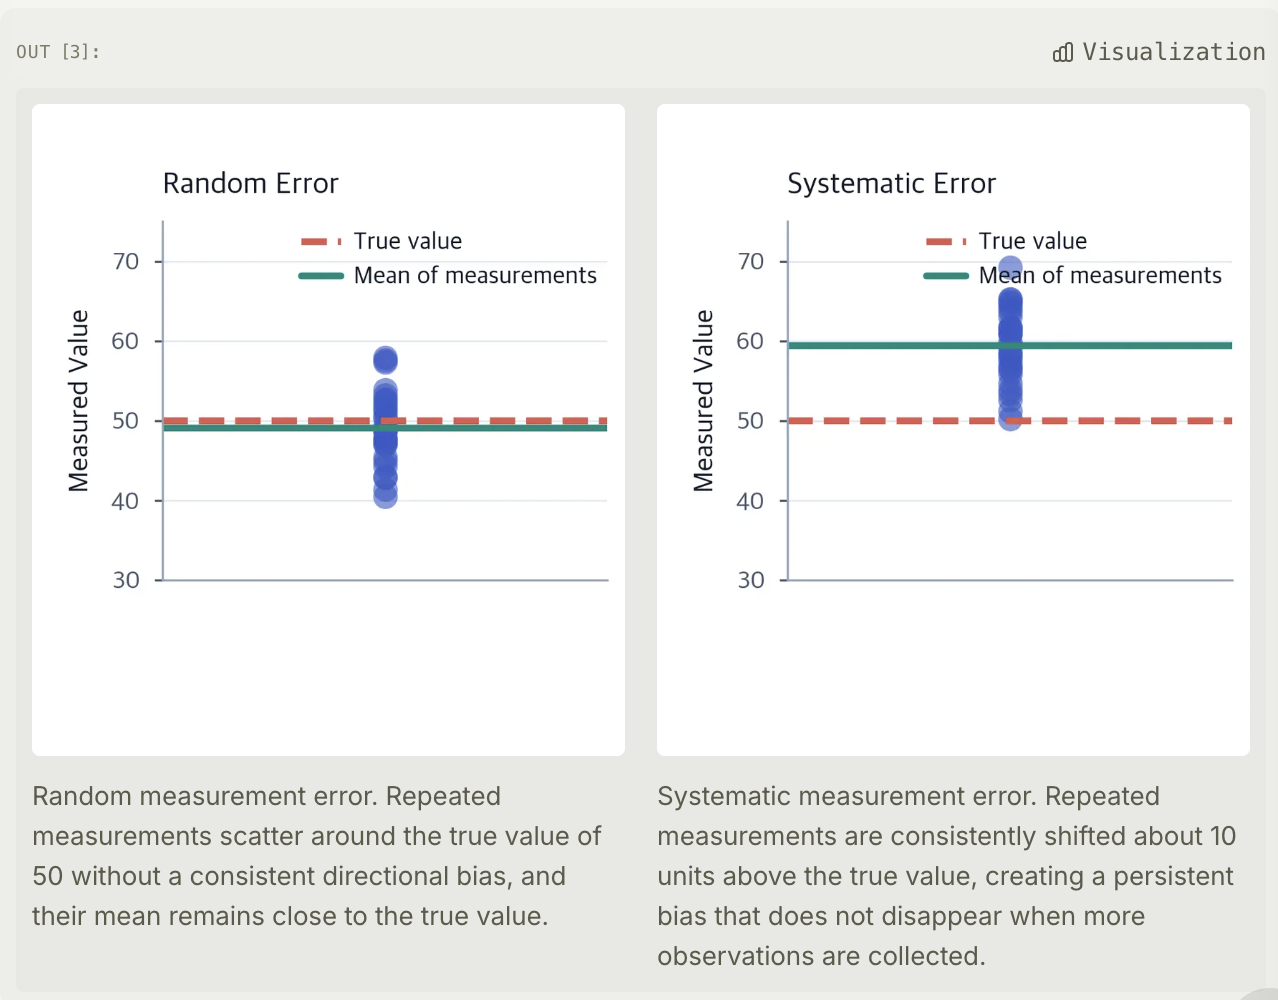


The next visualization demonstrates attenuation bias, showing how measurement error in independent variables weakens observed relationships. When X is measured with error, the regression slope becomes attenuated toward zero, systematically underestimating the strength of the true relationship.

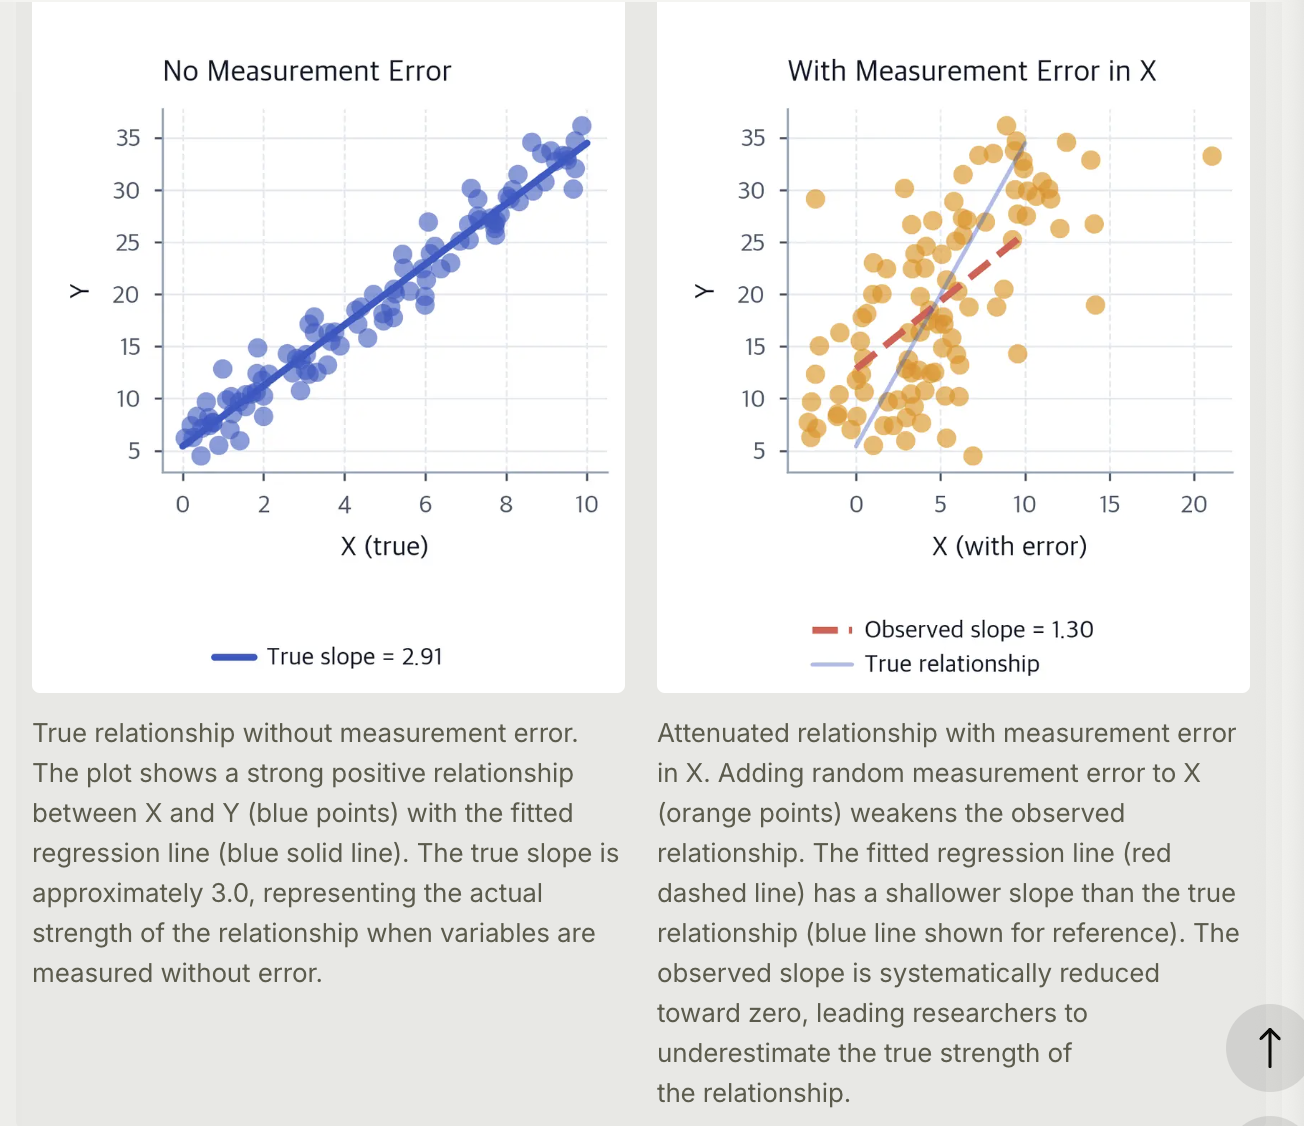


### Mitigation Strategies

While eliminating measurement error entirely is not feasible, careful study design and quality control procedures can minimize its impact. Using validated measurement instruments with documented reliability and accuracy provides a foundation for quality data collection. Regular calibration checks for physical instruments and pilot testing for surveys help identify problems before full-scale data collection begins.

Collecting multiple measurements of the same quantity and averaging them reduces random error, as independent random fluctuations partially cancel out. Taking three blood pressure readings and using their average provides a more reliable estimate than a single reading. Training data collectors thoroughly and monitoring their performance maintains consistency across measurers and over time.

When measurement error cannot be prevented, statistical methods can sometimes account for its effects. Measurement error models explicitly incorporate information about error magnitude to correct for attenuation bias. If the reliability of a measure is known from validation studies, regression coefficients can be disattenuated to recover estimates of true relationships. However, these corrections require strong assumptions and are not always feasible in practice.

## 3. Bias in Data Collections

Bias refers to systematic deviation of collected data from the true population values or relationships of interest. While measurement error operates at the level of individual observations, bias operates at the systematic level, producing datasets that misrepresent reality in consistent ways. Understanding sources of bias and their implications is fundamental to conducting valid statistical inference.

### Selection Bias

**Selection bias** occurs when the mechanism for including individuals in a sample is related to the outcome or relationships being studied. The resulting sample does not represent the target population, leading to estimates that do not generalize. This form of bias is particularly insidious because it cannot be corrected through statistical analysis alone: no amount of sophisticated modeling can recover the information lost by studying an unrepresentative sample.

**Survival Bias** provides a classic example. Studies of successful companies systematically oversample survivors who made it through competitive markets while missing failed companies that disappeared. Analyzing only survivors produces overly optimistic conclusions about business strategies because the sample excludes failures. Similarly, studies of elderly populations automatically exclude individuals who died young, potentially missing important risk factors that only manifest in premature mortality.

**Non-Response Bias** arises when individuals who choose to participate in surveys differ systematically from non-respondents. If a satisfaction survey achieves only a 20% response rate, the respondents likely differ in their satisfaction levels from those who ignored the survey. Highly satisfied and highly dissatisfied customers may be overrepresented relative to moderately satisfied customers who feel ambivalent about responding.


### Sampling Bias:
Even with perfect response rates, the sampling frame itself may introduce bias. If the list of potential participants used to draw the sample excludes or underrepresents certain groups, the resulting sample will be biased regardless of how randomly individuals are selected from that flawed frame. Historical examples include telephone surveys systematically missing households without landlines and internet surveys excluding populations with limited digital access.


Convenience sampling, where researchers collect data from easily accessible participants, virtually guarantees sampling bias. Recruiting study participants from university students, conducting surveys at shopping malls, or analyzing data from online volunteers all produce samples that differ systematically from the general population in ways that likely relate to the research questions of interest.


### Information Bias

Information bias occurs when systematic errors in measuring or classifying variables lead to distorted relationships in the data. Recall bias in retrospective studies exemplifies this problem: individuals asked to remember past exposures or behaviors may systematically misremember in ways correlated with their current health status. Mothers of children with birth defects, for instance, may recall prenatal exposures more thoroughly than mothers of healthy children, creating spurious associations.


Social desirability bias causes respondents to systematically misreport socially sensitive information, understating undesirable behaviors and overstating desirable ones. Self-reported data on income, exercise habits, alcohol consumption, and voting behavior are all susceptible to this bias, with the direction and magnitude varying across populations and contexts.



### Addressing Bias

Preventing bias requires careful attention during study design, as bias cannot be reliably corrected after data collection. Random sampling from a complete sampling frame that covers the target population gives the basis for unbiased inference. When true random sampling is infeasible, probability-based sampling with known inclusion probabilities allows weighting adjustments to recover population estimates.

For unavoidable non-response, collecting data on non-respondents through abbreviated surveys or administrative records enables assessment of non-response bias. If non-respondents differ systematically from respondents on observable characteristics, inverse probability weighting can partially correct for the bias, though unobserved differences remain problematic.

Blinding and objective measurement reduce information bias when feasible. If outcome assessors do not know participants' exposure status, their measurements cannot be influenced by that knowledge. Using administrative records or biomarkers instead of self-report eliminates recall and social desirability biases, though these alternatives introduce their own measurement challenges.




## 4. Missing Data

Missing data is ubiquitous in real-world datasets and poses significant challenges for statistical analysis. The appropriate strategy for handling missing values depends critically on the mechanism that generated the missingness, that is, why certain values are absent while others are observed.

### Mechanism of Missingness

The statistical literature distinguishes three mechanisms that generate missing data, each with different implications for analysis. *Missing Completely At Random (MCAR)* occurs when the probability that a value is missing is unrelated to any observed or unobserved variables in the dataset. If laboratory equipment randomly malfunctions, producing missing measurements that bear no relationship to the samples being processed or any other variables, the missingness is MCAR. Under MCAR, complete case analysis (simply deleting observations with missing values) produces unbiased estimates, though it reduces sample size and statistical power.


*Missing At Random (MAR)* describes situations where the probability of missingness depends on observed variables but not on the missing values themselves, conditional on the observed data. For example, if younger participants in a longitudinal study are more likely to skip follow-up surveys, but among participants of the same age, the missingness is unrelated to the variables being measured, then the missingness is MAR. Despite the potentially misleading name, MAR does not mean values are missing randomly. It means the missingness pattern can be explained by observed variables. Under MAR, complete case analysis produces biased estimates, but multiple imputation and maximum likelihood methods yield valid inference.

*Missing Not At Random (MNAR)* represents the most challenging scenario, where missingness depends on the unobserved values themselves even after conditioning on all observed variables. If individuals with higher incomes are less likely to report their income, and this relationship persists even after accounting for other observed characteristics, the missingness is MNAR. No general-purpose statistical method can correct for MNAR without making untestable assumptions about the relationship between missingness and the unobserved values.

### Diagnosing Missingness MechanismsLink Copied

Determining which missingness mechanism operates in a given dataset requires both statistical investigation and relevant domain knowledge. Visual exploration provides initial insights: plotting missingness patterns against observed variables can reveal relationships suggesting MAR rather than MCAR. If missing income values occur predominantly among respondents from wealthy neighborhoods, this pattern suggests MAR at minimum.

Formal tests for MCAR exist, though they have limitations. Little's MCAR test examines whether means of observed variables differ between observations with different patterns of missingness. Rejecting the null hypothesis of MCAR provides evidence against that mechanism, but failing to reject does not prove MCAR holds, as the test may simply lack power. More importantly, tests cannot distinguish MAR from MNAR, as the distinction hinges on relationships involving unobserved values.


Domain knowledge often provides the strongest evidence about missingness mechanisms. Understanding how and why data were collected reveals likely sources of missing values. Sensor failures that occur independently of measured values suggest MCAR. Survey fatigue leading to higher non-response for later questions suggests MAR if earlier responses predict dropout. Income non-response related to actual income levels represents MNAR.

The following visualization demonstrates how the three missingness mechanisms affect statistical analysis and why complete case analysis produces biased estimates under MAR and MNAR but not under MCAR.


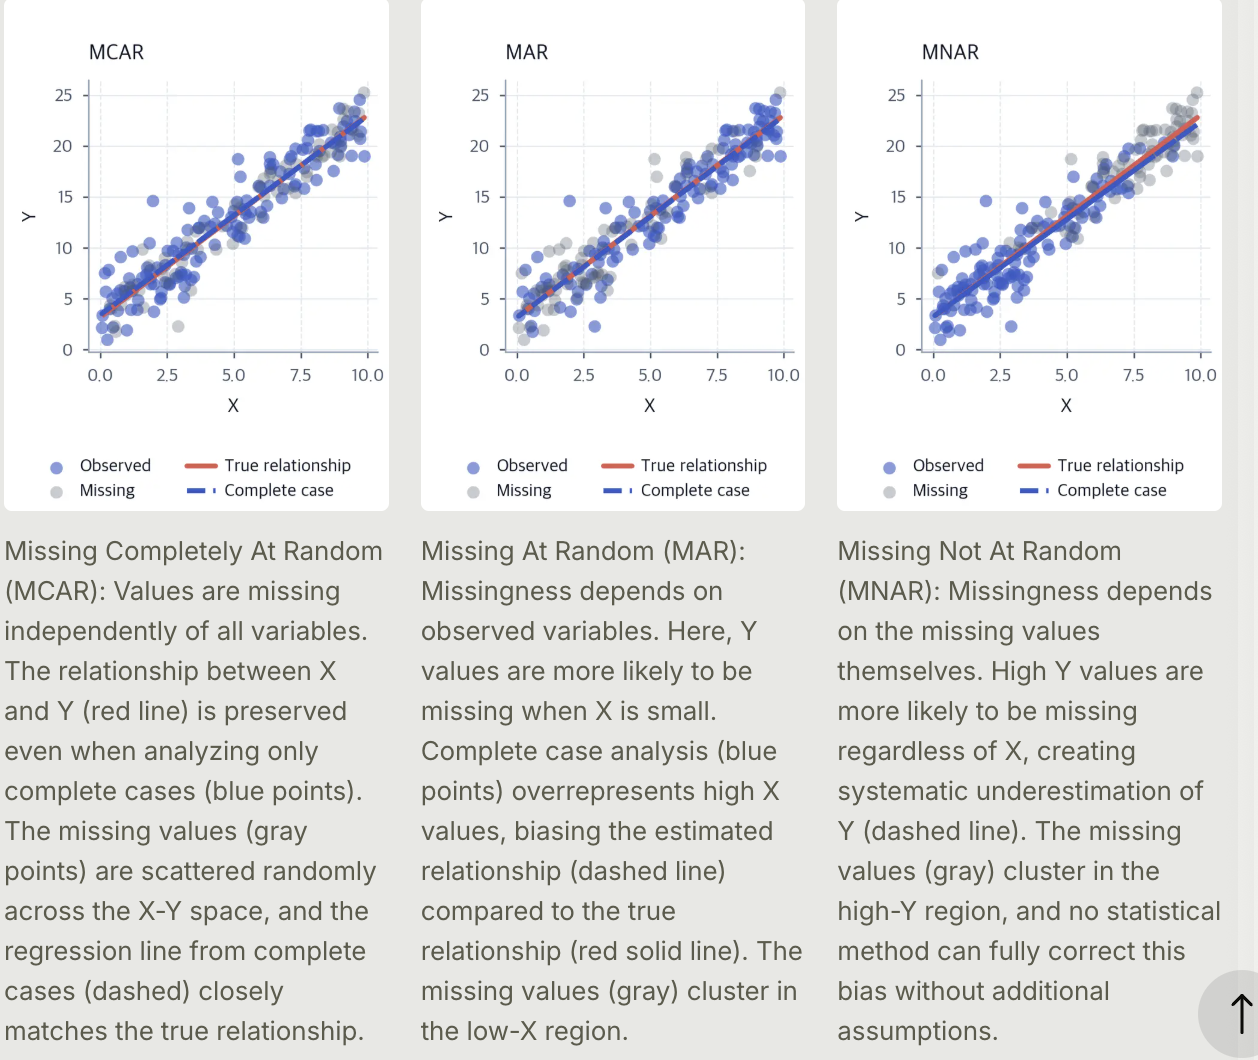

### Handling Missing Data

The choice of method for handling missing data should balance the plausibility of required assumptions against the analysis goals and available information. Complete case analysis, which analyzes only observations with no missing values, is simple and valid under MCAR but wasteful of data and biased under MAR or MNAR. When missingness is minimal and likely MCAR, this approach may be adequate.

Single imputation methods replace each missing value with a single estimated value based on observed data. Mean imputation fills missing values with the variable's average among observed cases, preserving the sample mean but artificially reducing variance and distorting correlations. Regression imputation predicts missing values from other variables using regression models, capturing relationships but still underestimating uncertainty by treating imputed values as if they were observed.

Multiple imputation represents current best practice for handling missing data under MAR assumptions. This approach creates multiple complete datasets by imputing missing values multiple times, each time incorporating appropriate randomness to reflect uncertainty about the true missing values. Each complete dataset is analyzed separately, and results are combined using Rubin's rules to produce final estimates and standard errors that properly account for imputation uncertainty. Multiple imputation requires specifying an imputation model relating missing variables to observed ones, which should be carefully considered based on domain knowledge.

Maximum likelihood methods provide an alternative to imputation that directly estimates parameters from the observed data without explicitly filling in missing values. These methods also assume MAR and can be more efficient than multiple imputation when the analysis model and missingness pattern are compatible. However, they are less flexible for complex analyses requiring multiple steps.


### Practical Considerations

When implementing any missing data method, transparency and sensitivity analysis are important. Document how much data is missing for each variable and the patterns of missingness across variables. Report whether analyses use complete cases, imputation, or maximum likelihood, and justify the choice. For important analyses, conduct sensitivity analyses comparing results across methods. If conclusions change dramatically depending on how missing data is handled, this fragility should be acknowledged.

Consider whether missing data itself carries information that should be preserved. In some contexts, the fact that a value is missing may be more informative than an imputed value. For instance, missing injury data in workplace safety records might indicate absence of injury, while imputation could introduce spurious variation. Creating indicator variables flagging missingness alongside imputed values allows analyses to capture both sources of information.

## 5. Outliers

Outliers are observations that deviate markedly from the overall pattern in the data. They command special attention because they can exert disproportionate influence on statistical summaries, regression estimates, and model predictions. The appropriate response to outliers requires careful judgment balancing legitimate extreme values against erroneous measurements.

### Types of Outlier

Outliers arise from different sources that warrant different responses. Data entry errors represent one common source: a recorded age of 250 or an income of $10 billion for a salaried employee clearly indicate mistakes that should be corrected or removed. These erroneous outliers provide no information about the population of interest and only distort analysis if retained.

Measurement errors produce outliers when instruments malfunction or reading errors occur. A temperature sensor reporting 500°F in an indoor environment or a laboratory result far outside physiologically possible ranges indicate measurement problems. Like data entry errors, these measurement outliers should be excluded or corrected when detected.

Natural variation generates legitimate outliers representing actual extreme values in the population. Some individuals truly are seven feet tall, some transactions truly involve millions of dollars, and some rare events truly occur despite low probability. These natural outliers are valid observations that reflect real phenomena, and removing them discards information about distributional tails that may be precisely what we want to understand.

Population heterogeneity produces outliers when a dataset inadvertently combines distinct subpopulations. A dataset containing both children and adults will show outliers when analyzing variables like height or income if the analysis treats all observations as coming from a single population. These outliers indicate misspecification rather than data quality problems. The solution is to model the populations separately or include covariates distinguishing them.

### Detection Methods

Multiple statistical and visual approaches help identify potential outliers. Visual inspection through box plots, scatter plots, and histograms gives intuitive identification of unusual values in univariate and bivariate contexts. Box plots flag observations beyond 1.5 times the interquartile range from the quartiles.

The z-score method identifies outliers based on how many standard deviations an observation falls from the mean. Values with |z| > 3 are commonly flagged, corresponding to observations more than three standard deviations from the mean. This approach assumes normality and can be misleading for skewed distributions where extreme values are expected. The median absolute deviation provides an alternative to standard deviation that is less influenced by the outliers being detected.

In regression contexts, outliers manifest in different ways requiring different diagnostics. Leverage measures how unusual an observation is in terms of predictor variable values, identifying points with potential to influence the fitted model. Influence measures like Cook's distance quantify how much regression estimates change when an observation is excluded, directly assessing impact on results. Residual plots reveal outliers in the response variable conditional on predictors.

The following visualizations demonstrate different approaches to identifying outliers, showing how box plots and regression influence diagnostics capture different aspects of unusual observations.

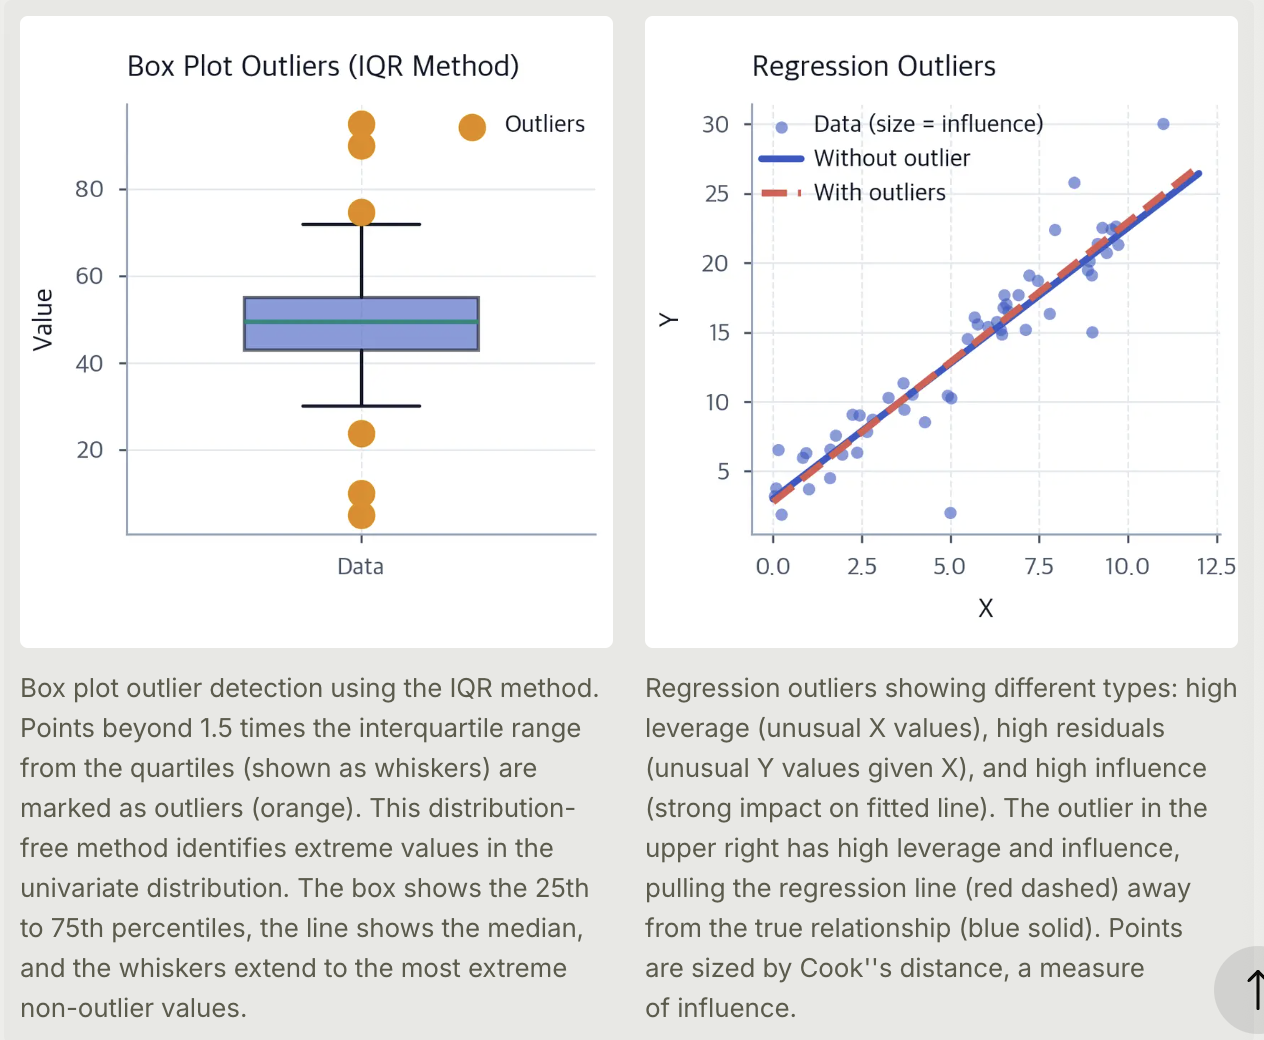


### Handling Outliers

The appropriate response to identified outliers depends on their suspected origin and the analysis goals. Investigation should precede action: examine outliers carefully to assess whether they represent errors, measurement problems, or legitimate extreme values. Check original data sources when possible to verify recorded values. Look for patterns in outliers that suggest systematic data quality issues.

For clearly erroneous outliers from data entry or measurement errors, correction or removal is appropriate and should be documented. Record the criteria used to identify errors and the number of observations affected. If the true value can be recovered from source documents, correction is preferable to deletion. Otherwise, treat erroneous values as missing data and apply appropriate missing data methods.

For legitimate extreme values representing natural variation, retention is generally appropriate as these observations provide information about the population. However, consider whether the extreme values warrant special attention in analysis. Reporting results both with and without outliers shows their influence and acknowledges uncertainty. Robust statistical methods that downweight outliers automatically, such as robust regression or trimmed means, provide alternatives to complete removal.

When outliers indicate population heterogeneity, stratified analysis or including appropriate covariates addresses the underlying issue. Analyzing subpopulations separately or modeling heterogeneity explicitly provides more appropriate inference than treating outliers as problems to be removed. This approach recognizes that "outliers" may represent a distinct but important segment of the population.

Transforming variables can reduce the influence of outliers without removing them. Logarithmic transformation compresses the right tail of positively skewed distributions, bringing extreme values closer to the bulk of the data. This approach works well for variables like income or reaction times where extreme values are legitimate but would otherwise dominate analyses. However, transformations change the scale of interpretation and may not be suitable for all purposes.

The following visualization shows how a single extreme outlier dramatically affects the mean while leaving the median relatively unchanged, illustrating the importance of robust statistics for skewed or outlier-prone data.


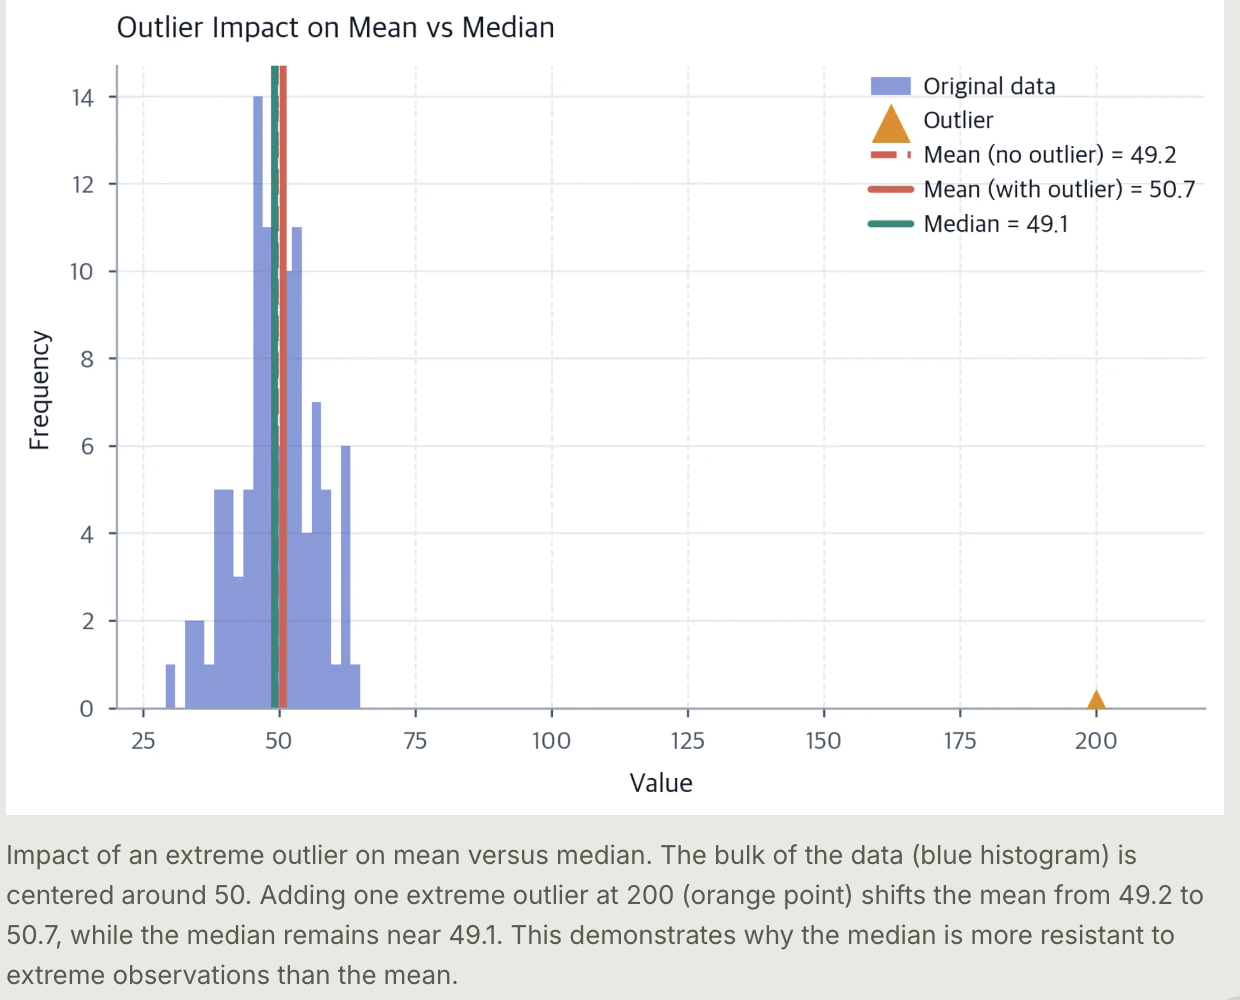

## 6. Practical Guidelines

Implementing data quality practices requires systematic workflows that integrate quality checks throughout the analysis pipeline rather than treating them as afterthoughts. Begin every project by profiling the data to understand how it is structured and distributed and where quality issues may occur before conducting the main analyses. Document all quality decisions transparently so that others can understand and evaluate the choices made.

### Data Profiling Workflows

Start by generating summary statistics for all variables, including counts of missing values, observed ranges, and measures of center and spread. These summaries often reveal obvious data quality problems immediately: negative ages, impossible dates, or values outside expected ranges indicate errors requiring investigation. Calculate missing data percentages for each variable and examine patterns of missingness across variables to understand whether missingness is isolated or systematic.

Create visualizations for each variable appropriate to its type. Histograms for continuous variables reveal distributional shape and potential outliers. Bar charts for categorical variables show frequency distributions and identify rare categories that might be data quality issues or legitimate rare values. Box plots highlight outliers efficiently. Time series plots reveal temporal patterns in data collection that might indicate systematic quality degradation.

Cross-tabulate related variables to identify impossible combinations. A dataset containing both birth year and age should show consistency between them. Discrepancies indicate errors in at least one variable. Geographic variables should form valid combinations (city-state-country), and categorical hierarchies should be logically consistent. These relationship checks catch errors that univariate summaries miss.


### Documenting Standards

Maintain detailed documentation of all data quality decisions throughout the analysis. Create a data quality log recording every issue identified, the investigation conducted, and the resolution implemented. For each excluded observation, document the reason for exclusion and the criteria applied. This transparency enables others to understand and evaluate your decisions, and helps you maintain consistency when similar issues arise later.

Report missing data percentages for all key variables in analysis reports. Explicitly state which missingness mechanism is assumed and which handling method was applied. If multiple imputation was used, report the number of imputations and the imputation model specification. For complete case analysis, report how many observations were excluded and whether excluded cases differ systematically from retained cases on observable characteristics.

When outliers are removed or treated specially, document the identification criteria and the number of affected observations. Report results both with and without outliers when feasible to show their influence on conclusions. If transformations are applied to address outliers or skewness, clearly state this and interpret results on the transformed scale appropriately.

### Quality Assuranc Practices

Implement automated checks that run each time data is updated or refreshed. These checks should verify that values fall within expected ranges, that required variables are present, that unique identifiers are indeed unique, and that relationships between variables remain consistent. Automated checks catch new errors introduced in data updates before they propagate into analyses.

For important analyses, conduct sensitivity analyses examining how conclusions change under different quality-related decisions. Compare results from complete case analysis, multiple imputation, and maximum likelihood estimation for missing data. Examine whether outlier treatment affects the main conclusions. If results remain consistent across reasonable alternatives, confidence in the findings increases. If results change dramatically, acknowledge this uncertainty and investigate which assumptions drive the differences.

Validate data against external sources when possible. Cross-reference aggregated statistics from your data against published values from administrative records or prior studies. Large discrepancies suggest potential data quality problems worth investigating. Conduct logical checks based on domain knowledge: are rates of rare diseases consistent with epidemiological literature? Are sales patterns consistent with known seasonality?

## 7. Limitations and Considerations

Data quality work involves inherent tradeoffs and calls for careful judgment. Perfect data quality is unattainable: even carefully collected data contains measurement error, missing values, and unusual observations. The goal is not perfection but understanding data limitations and managing their impact on conclusions appropriately.

Aggressive data cleaning can introduce its own biases. Excluding too many outliers creates datasets that underrepresent distributional tails, potentially missing important phenomena. Imputing missing data with overly simple methods can create artificial precision and distort relationships. Each quality-related decision involves balancing competing concerns, and different stakeholders may reasonably disagree about appropriate tradeoffs.

The boundary between legitimate extreme values and outliers requiring special treatment is often unclear. Statistical criteria like z-scores or Cook's distance provide screening tools but not definitive answers. An observation three standard deviations from the mean might be an error or a real rare event that warrants special attention precisely because it is unusual. Domain expertise must guide these judgments, supplemented by investigation of individual cases.

Missing data methods rely on untestable assumptions about missingness mechanisms. We can never definitively prove that data are MAR rather than MNAR, because the distinction depends on relationships involving unobserved values. Sensitivity analyses help understand how conclusions might change under alternative assumptions, but uncertainty remains. Report this uncertainty directly rather than implying more certainty than the data support.

Data quality work is time-consuming and rarely produces publishable results on its own, creating incentives to shortcut or skip quality checks. However, conclusions derived from poor-quality data are worse than useless: they are misleading. Building data quality practices into standard workflows, automating checks where possible, and recognizing quality work in project evaluations helps ensure appropriate attention to these foundational activities.


## Summary

Data quality fundamentally determines the validity of statistical analyses and machine learning models. Measurement error, bias, missing data, and outliers are inevitable features of real-world datasets that require careful attention rather than automatic application of standard fixes. Understanding the mechanisms that generate quality issues enables appropriate responses that balance data retention against error reduction.

Measurement errors come in random and systematic forms with different implications for analysis. Random error increases uncertainty but does not bias estimates systematically, while systematic error creates bias that persists regardless of sample size. Choosing instruments carefully and maintaining calibration and quality control minimize both types, though elimination is not feasible. Bias in data collection, arising from selection mechanisms, sampling frames, or measurement procedures, cannot be corrected statistically after data collection. Prevention through careful study design is important.

Missing data mechanisms determine which analytical approaches produce valid inference. Under MCAR assumptions, complete case analysis is unbiased though inefficient. MAR allows multiple imputation and maximum likelihood methods to recover valid estimates. MNAR requires untestable assumptions, creating irreducible uncertainty. Diagnosing missingness mechanisms through patterns in observed data combined with domain knowledge guides method selection, with transparent reporting of assumptions and decisions.

Outliers require investigation to distinguish errors from legitimate extreme values. Clear errors may be corrected or removed, while real extremes may call for methods resistant to outliers or sensitivity analyses. Visual inspection, statistical screening, and domain knowledge combine to identify and appropriately handle unusual observations. Removing too many outliers creates new biases by truncating distributions, while retaining severe errors distorts all downstream analyses.

Implementing effective data quality practices requires systematic workflows that integrate quality checks throughout analysis pipelines, complete documentation of decisions, and honest reporting of limitations. Data quality work involves judgment and tradeoffs rather than mechanical application of rules. Investing effort in understanding and improving data quality gives the basis for reliable, meaningful analyses that produce trustworthy insights.